In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [1]:
import pandas as pd

df = pd.read_json(
    "../data/raw/ember2018/train_features_5.jsonl",
    lines=True
)

print(df.shape)
df.head()

(202574, 14)


,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
0,c31950077f3dc66b0decad88326773cb74102c0da3007d...,ba2d2b60b02cf229acd85a66284b3e43,2018-09,1,high,"[39415, 6597, 5938, 5563, 5578, 6479, 5484, 47...","[14336, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 6134, 'avlength': 5.66856863384...","{'size': 1353344, 'vsize': 3784704, 'has_debug...","{'coff': {'timestamp': 1308078076, 'machine': ...","{'entry': '', 'sections': [{'name': '', 'size'...","{'kernel32.dll': ['GetModuleHandleA'], 'user32...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
1,3cf15185d9a5b5509e965c5c69ee6dd0a450dd03dd66f0...,0b057330f14dd95edcc4ed45e47f0117,2018-09,-1,agentb,"[238897, 17240, 6465, 8427, 15495, 4695, 4163,...","[67417, 14, 2, 15, 62, 11, 5, 6, 20, 4, 6, 3, ...","{'numstrings': 5280, 'avlength': 11.8875, 'pri...","{'size': 1130496, 'vsize': 1384448, 'has_debug...","{'coff': {'timestamp': 1437309093, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'WINMM.dll': ['waveOutUnprepareHeader', 'wave...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
2,15cbe38aa7edc72790993390e40e2e4e575c9d6ff32947...,5d09ec87cc3cfa05a3e12d95e7127dd9,2018-09,0,,"[20195, 1659, 287, 138, 145, 289, 82, 48, 731,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 155, 'avlength': 16.50322580645...","{'size': 39936, 'vsize': 61440, 'has_debug': 1...","{'coff': {'timestamp': 134726523, 'machine': '...","{'entry': '.text', 'sections': [{'name': '.tex...","{'msvcrt.dll': ['malloc', '_initterm', '_amsg_...","[DllCanUnloadNow, DllGetClassObject, DllRegist...","[{'name': 'EXPORT_TABLE', 'size': 192, 'virtua..."
3,153dc408a1d9866b0101a6f7f1394afd8e68c3c77788e7...,a6a51d562f565c9df84fde8185cd42eb,2018-09,0,,"[8720782, 8959, 5086, 4481, 7886, 4015, 3006, ...","[17065984, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 7690, 'avlength': 20.9416124837...","{'size': 9444776, 'vsize': 46145536, 'has_debu...","{'coff': {'timestamp': 1513732056, 'machine': ...","{'entry': '.data', 'sections': [{'name': '.tex...","{'QUARTZ.dll': ['AMGetErrorTextA'], 'COMCTL32....",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
4,e8abfa72e70bbf5629c8c507f2f66a9319606418cc4776...,224f0a2a455eb1b80e8fcf8acf808e3d,2018-09,0,,"[10078, 1007, 527, 610, 563, 295, 400, 178, 43...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 434, 'avlength': 12.68663594470...","{'size': 49568, 'vsize': 57344, 'has_debug': 1...","{'coff': {'timestamp': 1527653420, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'VCRUNTIME140.dll': ['__C_specific_handler', ...",[DllGetClassObject],"[{'name': 'EXPORT_TABLE', 'size': 100, 'virtua..."


In [2]:
df.tail()

,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
202569,68f325a3cce1ab28fa49a856c73bc3ce192073a6fdd8c0...,4078e0cde9be554b2dc6acc91011ee70,2018-10,1,ramnit,"[36455, 1885, 1585, 1569, 2065, 1282, 1273, 12...","[4048, 4, 7, 1, 5, 0, 9, 10, 0, 0, 1, 1, 3, 3,...","{'numstrings': 3289, 'avlength': 9.13286713286...","{'size': 265728, 'vsize': 278528, 'has_debug':...","{'coff': {'timestamp': 1208131890, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'msvcrt.dll': ['free', '_purecall', 'realloc'...","[DllCanUnloadNow, DllGetClassObject, DllRegist...","[{'name': 'EXPORT_TABLE', 'size': 163, 'virtua..."
202570,a75eacd3e4e90c891da6be58ec7838f2d621e4c048ebfc...,dfaa1bf08acca2de9f96c5d18dbdca2c,2018-10,1,wapomi,"[28581, 1334, 1189, 1161, 1328, 1116, 1004, 10...","[6142, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","{'numstrings': 2689, 'avlength': 7.59576050576...","{'size': 214016, 'vsize': 225280, 'has_debug':...","{'coff': {'timestamp': 1208131769, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'msvcrt.dll': ['malloc', 'realloc', '??2@YAPA...","[DllCanUnloadNow, DllGetClassObject, DllRegist...","[{'name': 'EXPORT_TABLE', 'size': 165, 'virtua..."
202571,652b9130302d33a370c2d26de42cb4983af7bfc286215b...,a1bca279ed442caf4d61487726bc24b1,2018-10,0,,"[114572, 6942, 3367, 2754, 5020, 3176, 1632, 1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 5347, 'avlength': 15.2038526276...","{'size': 801367, 'vsize': 3952640, 'has_debug'...","{'coff': {'timestamp': 708992537, 'machine': '...","{'entry': 'CODE', 'sections': [{'name': 'CODE'...",{},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
202572,6984c895dda5a0c02657b00d6993147a4f0a13c65a85db...,1ae647990e4cd602e87dfb05c0b8ffeb,2018-10,1,wapomi,"[34585, 1498, 1197, 1182, 1535, 1155, 1051, 10...","[8169, 0, 3, 4, 4, 1, 0, 1, 0, 3, 1, 2, 1, 1, ...","{'numstrings': 2750, 'avlength': 7.78509090909...","{'size': 233984, 'vsize': 241664, 'has_debug':...","{'coff': {'timestamp': 1324151142, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'msvcrt.dll': ['??_U@YAPAXI@Z', 'memcpy', 'me...","[DllCanUnloadNow, DllGetClassObject, DllRegist...","[{'name': 'EXPORT_TABLE', 'size': 163, 'virtua..."
202573,f16ecf10906fcb01b635c562278088f620c1fab6eb1a96...,7563fec04aa83bfbe27438fb045055f8,2018-10,1,ramnit,"[31253, 1584, 1290, 1277, 1646, 1182, 1068, 11...","[2048, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 2663, 'avlength': 7.62410814870...","{'size': 232448, 'vsize': 245760, 'has_debug':...","{'coff': {'timestamp': 1091606187, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'msvcrt.dll': ['??3@YAXPAX@Z', 'realloc', '??...","[DllCanUnloadNow, DllGetClassObject, DllRegist...","[{'name': 'EXPORT_TABLE', 'size': 165, 'virtua..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 202574 entries, 0 to 202573
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   sha256           202574 non-null  str   
 1   md5              202574 non-null  str   
 2   appeared         202574 non-null  str   
 3   label            202574 non-null  int64 
 4   avclass          202574 non-null  str   
 5   histogram        202574 non-null  object
 6   byteentropy      202574 non-null  object
 7   strings          202574 non-null  object
 8   general          202574 non-null  object
 9   header           202574 non-null  object
 10  section          202574 non-null  object
 11  imports          202574 non-null  object
 12  exports          202574 non-null  object
 13  datadirectories  202574 non-null  object
dtypes: int64(1), object(9), str(4)
memory usage: 21.6+ MB


In [4]:
df.dtypes

sha256                str
md5                   str
appeared              str
label               int64
avclass               str
histogram          object
byteentropy        object
strings            object
general            object
header             object
section            object
imports            object
exports            object
datadirectories    object
dtype: object

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [6]:
print(df["label"].value_counts())

label
 1    93521
 0    55662
-1    53391
Name: count, dtype: int64


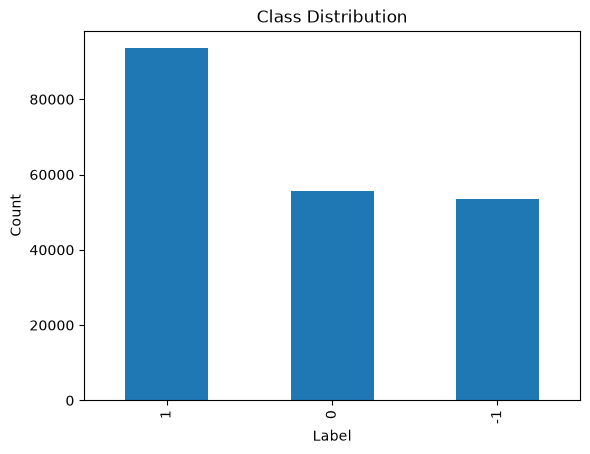

In [7]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [8]:
df.describe()

,label
count,202574.000000
mean,0.198100
std,0.828243
min,-1.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,1.000000


In [9]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

1236.8181915283203 MB


In [10]:
print(df.columns.tolist())

['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']


In [11]:
numeric_cols = df.select_dtypes(include="number").columns
print(numeric_cols)

Index(['label'], dtype='str')


In [12]:
for col in df.columns:
    print(col)

sha256
md5
appeared
label
avclass
histogram
byteentropy
strings
general
header
section
imports
exports
datadirectories


In [13]:
import pandas as pd
import os

os.makedirs("../reports/summaries", exist_ok=True)

summary = pd.DataFrame({
    "Dataset": ["train_features_5"],
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate SHA256": [df["sha256"].duplicated().sum()],
    "Memory (MB)": [round(df.memory_usage(deep=True).sum()/(1024**2), 2)],
    "Malware Samples": [(df["label"] == 1).sum()],
    "Benign Samples": [(df["label"] == 0).sum()],
    "Unknown Samples": [(df["label"] == -1).sum()]
})

summary.to_csv("../reports/summaries/train_5_summary.csv", index=False)

print("Summary Saved!")

Summary Saved!
